# EDA — Engagement: Feed CTR, Dwell, Contact & Content Quality

**Active engagement:** user không chỉ pageview mà còn `other_interaction` (soi ảnh/mô tả) và/hoặc contact.

| Góc | Nội dung |
|-----|----------|
| **1** | CTR proxy theo `position`; ngôi sao / hố đen trên feed |
| **2** | Dwell buckets, dwell × `listing_age_days`, bẫy dwell cao–contact thấp |
| **3** | Contact mix theo `device`; decay `views_24h`/`contacts_24h`; desperation pattern |
| **4** | `other_interaction` → contact; dwell phân phối; content blackholes; funnel 4 bước |

**Lưu ý data:** Không có log impression thuần → CTR dùng **proxy** (pageview có `position` / exposure `views_24h`).

**Viz:** chart trong output, trục **%**. PNG → `outputs/eda_engagement/`. RAM: sample mặc định ~8%.

In [3]:
from __future__ import annotations

import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)

# --- RAM ---
DUCKDB_MEMORY_LIMIT = "2GB"
DUCKDB_THREADS = 2
EVENT_SAMPLE_FRAC = 0.08   # None = full scan; hoặc 8 → TABLESAMPLE 8% SYSTEM
CATEGORIES_TO_RUN = [1010, 1020, 1030, 1040, 1050]

DATA_ROOT = Path.cwd().resolve()
OUT_DIR = DATA_ROOT / "outputs" / "eda_engagement"
OUT_CSV = OUT_DIR / "g4_tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV.mkdir(parents=True, exist_ok=True)

EVENTS_GLOB = str(DATA_ROOT / "fact_user_events" / "*.parquet")
SNAP_GLOB = str(DATA_ROOT / "fact_listing_snapshot" / "*.parquet")
DIM_GLOB = str(DATA_ROOT / "dim_listing" / "*.parquet")
INTER_GLOB = str(DATA_ROOT / "fact_post_contact_interactions" / "*.parquet")

EXPLICIT_TYPES = ("view_phone", "contact_chat", "contact_zalo", "contact_sms")
EXPLICIT_SQL = ", ".join(repr(x) for x in EXPLICIT_TYPES)
DATATHON_POSITIVE_TYPES = EXPLICIT_TYPES + ("other_interaction",)  # README only — không dùng làm lead KPI
POSITIVE_TYPES = DATATHON_POSITIVE_TYPES
pos_list = ", ".join(repr(x) for x in POSITIVE_TYPES)

CAT_META = pd.DataFrame([
    (1010, "1010 — Căn hộ / Chung cư"),
    (1020, "1020 — Nhà ở"),
    (1030, "1030 — Văn phòng / Mặt bằng"),
    (1040, "1040 — Đất"),
    (1050, "1050 — Phòng trọ"),
], columns=["category", "category_name"])
PALETTE = {1010: "#238b45", 1020: "#2171b5", 1030: "#6a51a3", 1040: "#cb181d", 1050: "#d94801"}


def pct_share(s: pd.Series) -> pd.Series:
    t = float(s.sum())
    return (s / t * 100.0) if t else s.astype(float)


def pct_row(df: pd.DataFrame) -> pd.DataFrame:
    return df.div(df.sum(axis=1), axis=0) * 100.0


def sample_clause(frac) -> str:
    return "" if frac is None else f"AND random() < {float(frac)}"


def pos_bucket(p) -> str:
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return "unknown"
    p = int(p)
    if p <= 5:
        return "1-5"
    if p <= 10:
        return "6-10"
    if p <= 20:
        return "11-20"
    return "21+"


def show_and_save(name: str, **kwargs):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", **kwargs)
    plt.show()
    print("Saved", path)


con = duckdb.connect(":memory:")
con.execute(f"PRAGMA memory_limit='{DUCKDB_MEMORY_LIMIT}'")
con.execute(f"PRAGMA threads={DUCKDB_THREADS}")
print("OUT_DIR =", OUT_DIR, "| sample =", EVENT_SAMPLE_FRAC)



OUT_DIR = /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement | sample = 0.08


## Góc 1 — Feed CTR proxy theo `position`

<IPython.core.display.Markdown object>


,pos_bucket,pageviews,pct_of_clicks
0,1-5,276903,43.037056
1,6-10,105526,16.401153
2,11-20,111269,17.293746
3,21+,149708,23.268045


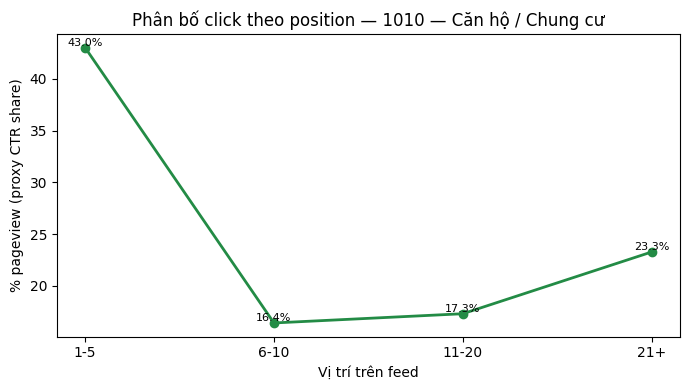

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g1_ctr_position_1010.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Ngôi sao:** median position ≥ 15 (xa trên feed) nhưng pageview cao

,item_id,pageviews,med_position,exposure,ctr_proxy_pct
476,4649d4f73ca44702662e589fb05b2454c83c27bbc7a80a...,86,16.5,1246.0,6.902087
1079,b46c4c02770631aecca27425e7fef815e69225ef1b2002...,80,18.5,1078.0,7.421150
25562,0e59ce2b42b6f81300a39dce61b62319c21882e5a5786b...,78,16.5,1355.0,5.756458
27315,a66bd651dd5dc12b73803d1e482dded5a7c08375b0b273...,77,15.0,1029.0,7.482993
3000,37a04cdfd393acebfd9ba1c62ba8d487d2b95928560f34...,72,15.0,1117.0,6.445837
39936,8a4d184b2b18161896164f65ca727b591a60e386d6ec9e...,72,17.5,0.0,NaN
22032,ed52743c00bc99047dba21e9d1a5d9cd585b208d69668d...,67,16.0,933.0,7.181136
23826,7290102af046dae8380242de980dd3d4dce85faf5db5bb...,61,16.0,776.0,7.860825
36577,3e512e2a17acb77db147461524e14e6d73dd9dacecc46a...,60,15.0,1023.0,5.865103
27011,478ca17573c11f6be106ef9670a61376fa634fdb7011eb...,58,15.5,920.0,6.304348


**Hố đen:** exposure cao (views_24h) nhưng CTR proxy thấp, click khi position top

,item_id,pageviews,med_position,exposure,ctr_proxy_pct
8310,162b3ad821746da74de249318a3d9595b6697af2592b83...,5,3.0,350.0,1.428571
2175,7c427fcdca044e201198bb5a15ca809d5055fdf6090333...,6,1.0,359.0,1.671309
35083,65307327223bade8cfe9831225bf0a209b3ce5e336f6a1...,8,1.5,433.0,1.847575
36172,34b981b4df7ac958d40fc8dac1222dd750b7b487019614...,5,3.0,248.0,2.016129
14135,c6abed41529273eb865dbd1549468d50cfa29e4950648b...,6,2.0,286.0,2.097902
22924,aae19d7d6519d845731501f33c41e02ede49d9bfd6ef23...,5,1.0,238.0,2.100840
28323,8fc278eba8fa61d773f67882e7a01acaba2a0dee3d35dd...,5,1.0,237.0,2.109705
517,3082b30e2274f42ca34043bc55c9e441aa9477cbf4aa4f...,6,3.0,281.0,2.135231
14611,5c5608c3a6ca5ec77be5e023310e67b24bb8df07c272b5...,5,1.0,234.0,2.136752
34718,babad3ffc590821acc9a9f5767440a842e949d4ed692e2...,7,1.0,325.0,2.153846


<IPython.core.display.Markdown object>


,pos_bucket,pageviews,pct_of_clicks
0,1-5,647310,36.549278
1,6-10,280969,15.864445
2,11-20,331952,18.743115
3,21+,510830,28.843162


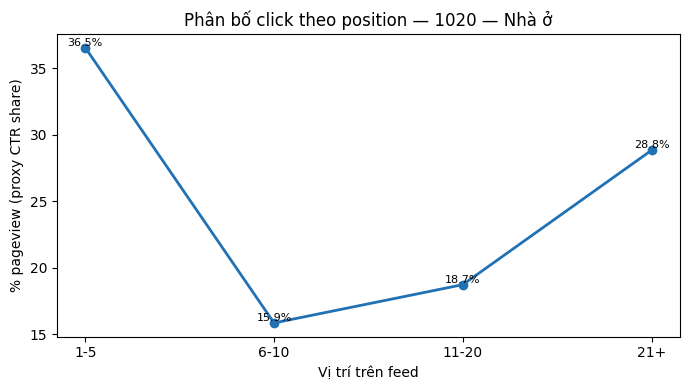

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g1_ctr_position_1020.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Ngôi sao:** median position ≥ 15 (xa trên feed) nhưng pageview cao

,item_id,pageviews,med_position,exposure,ctr_proxy_pct
16706,607fb0b6d3775ac0136f5dd90726a39261c7bfa37ceccc...,161,17.0,2025.0,7.950617
628,ee0596d21fdd0105d5765bd9b1e260cf9515f67ec2f3a5...,125,29.0,1600.0,7.812500
104686,989993ab4762dfda9fa19cbd479ba96cc27c0f48763349...,117,18.0,0.0,NaN
16032,c7b210aa7d768a33f82d5e66a57d4882544478d89f64cb...,116,15.5,1443.0,8.038808
20522,8f43eae91edd50bbb92a5da424f27820e9b8684d372ea2...,112,15.5,1260.0,8.888889
34255,1aafbd06636a5f58fa1f4832ca142267ad0ea74b5688f5...,108,18.0,1488.0,7.258065
29102,9069ef46eb4cc0433ea0480d8179f861c0df4b43fc04c2...,105,17.0,1546.0,6.791721
27764,6fb2c8e4375756e50c914a00af8b4d6cfd17a8e1a20a4b...,104,15.0,1612.0,6.451613
23095,ffd979641ba40223aae7730fc38407f8ff06f2e6a2f392...,103,21.0,1399.0,7.362402
9001,49bc745e98949f1038ed4c1405eae7e5a1020751d2a214...,97,15.0,1232.0,7.873377


**Hố đen:** exposure cao (views_24h) nhưng CTR proxy thấp, click khi position top

,item_id,pageviews,med_position,exposure,ctr_proxy_pct
8637,d4b63c9a4d7388302a104a03837b9fd5475fe22750e904...,5,2.0,613.0,0.815661
53646,f4d7875a3e8cda37866a76d794845c3d2db57122f969ea...,8,0.5,656.0,1.219512
67324,3871f552de2347c5f86444015566621571f6c278bdd915...,5,2.0,344.0,1.453488
61445,fd7747b52badb85e218e7cde514e7e93fba6823eeede41...,5,2.0,313.0,1.597444
42192,ca1c38417651dcec2b0067ae490c82651994e68443ade1...,8,1.0,500.0,1.600000
15429,23b2dcfce0bc7cb4dbd337efef634d2f427e41b3bd1f92...,5,2.0,303.0,1.650165
47857,19b6fa3db9745f8ff98a0084c86e3ca458ff148e42d712...,7,3.0,420.0,1.666667
5719,554fec9192dbb4d8e4ff60bfc4a9ce378aff50256bc8c6...,5,1.0,279.0,1.792115
650,8c4efea17c77c886a2404abfcb6d3e00ed3efcd89e79ca...,5,3.0,268.0,1.865672
91920,de91448cfaa309f778daef06363367b537bfca1092844f...,6,1.0,314.0,1.910828


<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pos_bucket,pageviews,pct_of_clicks
0,1-5,90982,33.788391
1,6-10,38546,14.315000
2,11-20,48721,18.093735
3,21+,91021,33.802874


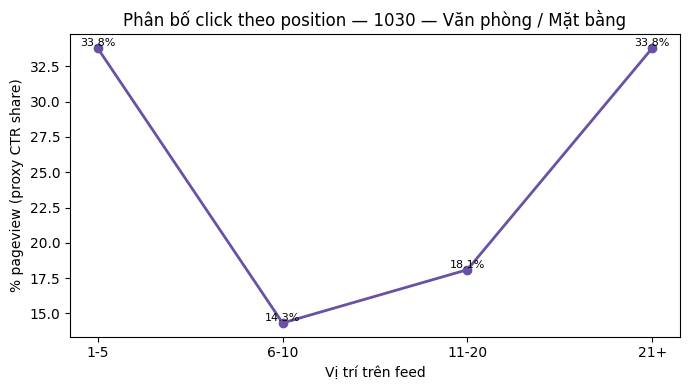

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g1_ctr_position_1030.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Ngôi sao:** median position ≥ 15 (xa trên feed) nhưng pageview cao

,item_id,pageviews,med_position,exposure,ctr_proxy_pct
5328,f423cba485c6039d735c44ba74144c8d8e824d76455238...,130,17.0,1630.0,7.975460
3011,031ea000d1aadf5dd70a9e1eed1b231ffacaa3f587891b...,128,17.5,1600.0,8.000000
73,62f70e5a1b013fb0685abb530ff2d2531b6d820e9ff1bb...,103,16.0,1125.0,9.155556
8818,1ea9d0dacb78cffed19343fb45fbaada9c07b1d3f27e62...,102,15.0,1859.0,5.486821
10573,2b721c34d2cf4e1a0da43de787d33b53d7ebfefc87d391...,98,15.0,1068.0,9.176030
2112,280fe24432b2f29bc03668478830832b55b76e53e10fda...,97,16.0,1162.0,8.347676
6089,4d7e194f246bed1eac4f18d9ff9807f2b475387eda22e4...,91,18.0,1005.0,9.054726
7786,1bbdebaa1f4f43c22cf81b9bb2fe2cb8294cd41662c94a...,81,26.0,982.0,8.248473
1543,685e114eda9e0685057fbee8f3fc58fa47052d9cda8544...,78,17.0,918.0,8.496732
2167,208934f6b1f577b20393e3a8196eb55b0a86c5aece2668...,76,20.0,919.0,8.269859


**Hố đen:** exposure cao (views_24h) nhưng CTR proxy thấp, click khi position top

,item_id,pageviews,med_position,exposure,ctr_proxy_pct
11575,6b70dd5366260696a13535aab4954eb43bba5403b531ea...,5,1.0,274.0,1.824818
5727,9ed8ead6d08b73568af76308f618b0c7f5b7ee15c2be7d...,6,1.0,317.0,1.892744
12875,13ea82ac7e46d1dd305e5e138246ce7365f377e01d47f9...,5,2.0,246.0,2.032520
15533,6cbb7c0cc6a164caff889a379bee6e0840d5a0b29fafcb...,7,1.0,318.0,2.201258
17148,ee379ee8ed7a04a9c83dcc2d02d553137ad6031655d385...,5,2.0,221.0,2.262443
10176,8edad0d50985747bf083c991de0efb845671a88b5dead5...,5,1.0,219.0,2.283105
15037,90e84ebf8a343be698b43a783332af72389143233db2e7...,5,1.0,218.0,2.293578
10351,351e9795f9b645c8defe2e4c7c3a836af0fdfb1ace3175...,7,3.0,295.0,2.372881
12345,d2550678185771794e14a36381ee3eed845a98710be870...,7,3.0,295.0,2.372881
15526,bfcaa319ab04a928dbb3dea757023521cca7841133b358...,5,1.0,208.0,2.403846


<IPython.core.display.Markdown object>


,pos_bucket,pageviews,pct_of_clicks
0,1-5,152204,40.929687
1,6-10,58170,15.642689
2,11-20,64773,17.418324
3,21+,96720,26.009299


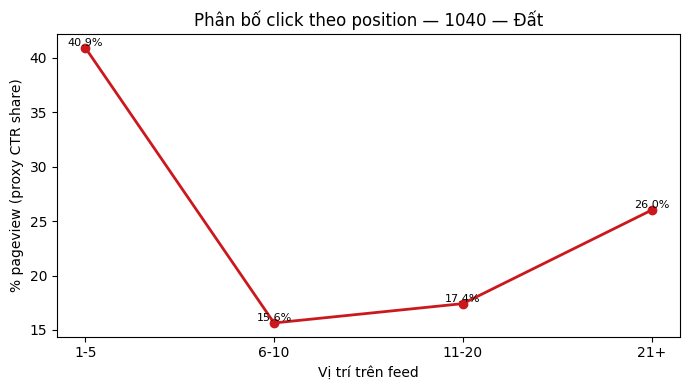

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g1_ctr_position_1040.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Ngôi sao:** median position ≥ 15 (xa trên feed) nhưng pageview cao

,item_id,pageviews,med_position,exposure,ctr_proxy_pct
3739,288d1ea829c09fae608700645c566bd70f41dce8b171ed...,92,19.5,1097.0,8.386509
1442,595801cda93314c9a0751f7429ad91e9951e646967071c...,83,17.0,1294.0,6.414219
5183,03f827faac3dec4be6a64010914d543f60431fe0546b64...,79,16.0,1116.0,7.078853
8084,262973e1f565983ed0463a8f4085b790d176e55b320b86...,67,16.0,688.0,9.738372
10765,e27e97eaf91bfc6616dd3a2d713cc57ef1fd99bd421162...,62,16.5,829.0,7.478890
6356,957c1aaf69a7cf2d4ecd942ff3b571503cdc358c47a0cd...,57,30.0,811.0,7.028360
6430,50ea4910d4ea46b3034a347562482869431107e0c2654f...,55,33.0,662.0,8.308157
7055,cc0586f3c619178ef34bd1e2370f646fef789ac59b027b...,54,19.0,694.0,7.780980
7884,39e7b1e2bbf970b95e022bbd0a2080624bf93c6179488c...,54,16.5,636.0,8.490566
10328,92956a7758caf754a2144f1e939008a7d1cebfe5e56fd8...,54,16.0,730.0,7.397260


**Hố đen:** exposure cao (views_24h) nhưng CTR proxy thấp, click khi position top

,item_id,pageviews,med_position,exposure,ctr_proxy_pct
6711,afa2e31bd4bc2709b809c445409987b6137e40a48fcaa1...,5,1.0,227.0,2.202643
8726,4b464133a07066658c1c4d087ab2d9c40129ff4b8755f1...,5,2.0,219.0,2.283105
3107,7bfb05f5037fa33f70eae310ed6a480591df133429113b...,6,1.5,262.0,2.290076
6811,f9b46b439e464da8f03f7955dbb9b560aa54779a62f89a...,7,1.0,299.0,2.341137
8178,4315a9e821a6f5c99a5a01aad53b423a4aebaeb6f94215...,5,2.0,210.0,2.380952
1668,b6a61c59f097a23d393e7bf69d79a96b3eafe520c6362f...,8,1.5,325.0,2.461538
17953,4896d08ec063363ff061469ccf388a6493118d8564dce0...,8,1.0,323.0,2.476780
19314,177b8d46ed5298c7d97b47689c215b971266726967a4d5...,5,3.0,194.0,2.577320
2992,44a777316b9c72bacf02a90a63f866d8a9e5b5cde27ce1...,5,2.0,193.0,2.590674
17915,b2e669a03cea0bf2fecaeef371ba853cc4373fa47e17c3...,7,1.0,270.0,2.592593


<IPython.core.display.Markdown object>


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pos_bucket,pageviews,pct_of_clicks
0,1-5,420769,35.379670
1,6-10,181772,15.284000
2,11-20,219275,18.437378
3,21+,367480,30.898952


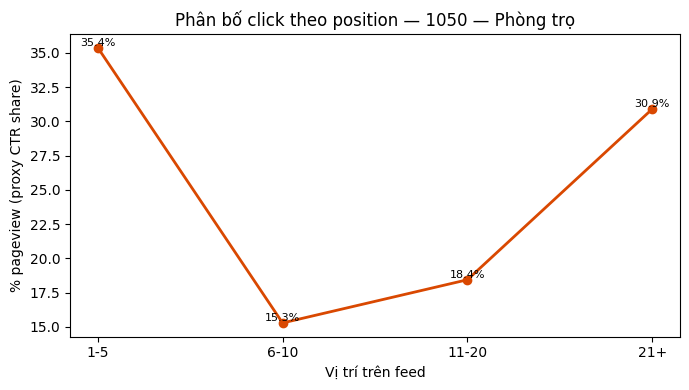

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g1_ctr_position_1050.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Ngôi sao:** median position ≥ 15 (xa trên feed) nhưng pageview cao

,item_id,pageviews,med_position,exposure,ctr_proxy_pct
9070,8974820ca7cf89cd65d78641c5bfd560949943cd7cfe81...,733,15.0,9812.0,7.470444
4273,19ba3b3e84669dce2f99197aeb27290d8c0860f9933f93...,566,18.0,8199.0,6.903281
47788,b3df3ef6555fd0f55190dd37ab48addac8d1f57c2b5656...,510,17.0,0.0,NaN
47752,4579bd69338766a220044ae6e199f87b43b7d30b148413...,465,17.0,0.0,NaN
47689,3de4de71a4bcb8bc3732fd1719c6e63f35b1697f1e7ab3...,460,15.0,0.0,NaN
47750,ac34ac917fe2de074cd7b4a75ec8ca8b0b85aae5ecccdc...,459,16.0,0.0,NaN
4512,39baa0bd141e6bb1d3b33d78985b2dc065002f4d438b17...,454,16.0,5562.0,8.162531
47854,ce60a2d9599ac0714a2ff762ab96a764b874a1189a620e...,402,15.0,0.0,NaN
14720,23af11d4d764a14ea28f8542e40173a56016cd437f46c1...,396,16.0,5502.0,7.197383
4513,a2fc1088eaf7ccd9e4470429389fec1dd1efa84db745a2...,376,17.0,5267.0,7.138789


**Hố đen:** exposure cao (views_24h) nhưng CTR proxy thấp, click khi position top

,item_id,pageviews,med_position,exposure,ctr_proxy_pct
2464,82b292880c04f7f86f7f4eb21637b6f9ead868fa33c23e...,10,1.0,450.0,2.222222
16327,7ee88f71a8b7b7166a4df4fc741327cbd5df5eb50da421...,10,1.0,414.0,2.415459
17586,6994385e4143e4b814627442cf9b1156e5a3a304e3d85b...,13,1.0,513.0,2.534113
4759,58c04c9e3298c9d3e6b7f7a966cd6071a8489aea24db16...,21,3.0,814.0,2.579853
16329,c29674ef4a53f8e633a37c0b8b64732b329f48a42e9340...,12,1.0,452.0,2.654867
4740,ab772af568799f60118a76cabfe08fa440c135897fdd24...,12,2.5,444.0,2.702703
3880,d083d89dc3c41899643e5492e92360c89d0108ad989de1...,12,1.0,443.0,2.708804
2246,7939edf4a6843f5260161dd13b6b48b3e03955da1eea4b...,12,1.0,424.0,2.830189
5068,757f3b13cc6430edfa1db6a066f40934e03b9762bc4f18...,14,1.5,492.0,2.845528
70,69fde23e0185221307b4f3660ec7ad8e80ab71e6772fea...,23,3.0,800.0,2.875000


In [4]:
def ctr_by_position(cat: int) -> pd.DataFrame:
    w = sample_clause(EVENT_SAMPLE_FRAC)
    return con.execute(
        f"""
        WITH pv AS (
            SELECT CAST(position AS INT) AS pos
            FROM read_parquet(?)
            WHERE category = ? AND event_type = 'pageview'
              AND position IS NOT NULL AND position >= 1
              {w}
        ),
        b AS (
            SELECT
                CASE
                    WHEN pos <= 5 THEN '1-5'
                    WHEN pos <= 10 THEN '6-10'
                    WHEN pos <= 20 THEN '11-20'
                    ELSE '21+'
                END AS pos_bucket,
                COUNT(*)::BIGINT AS pageviews
            FROM pv GROUP BY 1
        )
        SELECT pos_bucket, pageviews,
               pageviews * 100.0 / SUM(pageviews) OVER () AS pct_of_clicks
        FROM b ORDER BY CASE pos_bucket
            WHEN '1-5' THEN 1 WHEN '6-10' THEN 2 WHEN '11-20' THEN 3 WHEN '21+' THEN 4 ELSE 5 END
        """,
        [EVENTS_GLOB, cat],
    ).fetchdf()


def stars_and_blackholes(cat: int, top_n: int = 50) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Star: median position cao + nhiều pageview. Black hole: position thấp + views cao (snapshot) nhưng ít click."""
    w = sample_clause(EVENT_SAMPLE_FRAC)
    items = con.execute(
        f"""
        WITH pv AS (
            SELECT item_id,
                   COUNT(*)::BIGINT AS pageviews,
                   MEDIAN(CAST(position AS DOUBLE)) AS med_position
            FROM read_parquet(?)
            WHERE category = ? AND event_type = 'pageview' AND item_id IS NOT NULL
              AND position IS NOT NULL {w}
            GROUP BY item_id
            HAVING COUNT(*) >= 5
        ),
        exp AS (
            SELECT s.item_id, SUM(s.views_24h)::DOUBLE AS exposure
            FROM read_parquet(?) s
            INNER JOIN read_parquet(?) d ON s.item_id = d.item_id
            WHERE d.category = ?
            GROUP BY s.item_id
        )
        SELECT p.item_id, p.pageviews, p.med_position,
               COALESCE(e.exposure, 0) AS exposure,
               CASE WHEN COALESCE(e.exposure, 0) > 0
                    THEN p.pageviews * 100.0 / e.exposure ELSE NULL END AS ctr_proxy_pct
        FROM pv p
        LEFT JOIN exp e ON p.item_id = e.item_id
        """,
        [EVENTS_GLOB, cat, SNAP_GLOB, DIM_GLOB, cat],
    ).fetchdf()
    if items.empty:
        return items, items
    pv_p90 = items["pageviews"].quantile(0.9)
    stars = items[(items["med_position"] >= 15) & (items["pageviews"] >= pv_p90)].nlargest(top_n, "pageviews")
    holes = items[(items["med_position"] <= 3) & (items["exposure"] >= items["exposure"].quantile(0.75)) &
                  (items["ctr_proxy_pct"].fillna(100) <= items["ctr_proxy_pct"].quantile(0.25))].nsmallest(top_n, "ctr_proxy_pct")
    return stars, holes


for cat in CATEGORIES_TO_RUN:
    name = CAT_META.loc[CAT_META["category"] == cat, "category_name"].iloc[0]
    print(Markdown(f"### Góc 1 — {name} ({cat})"))
    ctr = ctr_by_position(cat)
    display(ctr)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(ctr["pos_bucket"], ctr["pct_of_clicks"], marker="o", color=PALETTE[cat], lw=2)
    ax.set_ylabel("% pageview (proxy CTR share)")
    ax.set_xlabel("Vị trí trên feed")
    ax.set_title(f"Phân bố click theo position — {name}")
    for x, y in zip(ctr["pos_bucket"], ctr["pct_of_clicks"]):
        ax.text(x, y, f"{y:.1f}%", ha="center", va="bottom", fontsize=8)
    show_and_save(f"g1_ctr_position_{cat}.png", dpi=150)
    stars, holes = stars_and_blackholes(cat)
    display(Markdown("**Ngôi sao:** median position ≥ 15 (xa trên feed) nhưng pageview cao"))
    display(stars.head(10))
    display(Markdown("**Hố đen:** exposure cao (views_24h) nhưng CTR proxy thấp, click khi position top"))
    display(holes.head(10))




## Góc 2 — Dwell time & listing age

<IPython.core.display.Markdown object>


,dwell_band,n,pct
0,unknown,75579,9.225862
1,skim_5-15s,390,0.047607
2,engaged_15s+,740771,90.425264
3,bounce_<5s,2468,0.301267


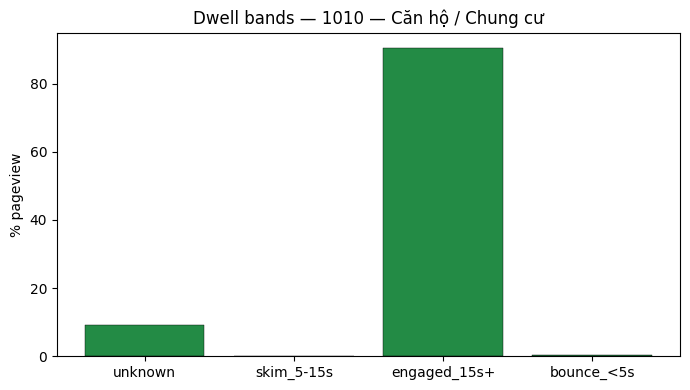

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g2_dwell_bands_1010.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,age_band,avg_dwell,n
0,0-2d,55475.518683,179597
1,3-7d,51362.924447,126295
2,8d+,54019.177797,434900


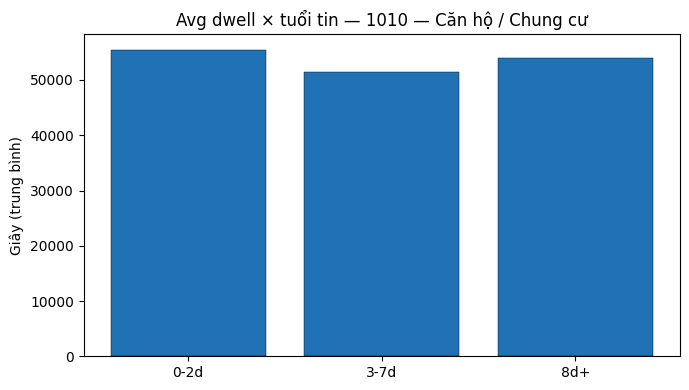

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g2_dwell_listing_age_1010.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Bẫy:** dwell cao, contact ≈ 0

,item_id,avg_dwell,pageviews,contacts
0,a0595597e337974dc52ad6a07cba49cb24b76b8487b349...,3092207.0,1,0
1,ddb2334c064239babb4b54c1dbb7f87d701f58af5b63bf...,2379857.0,1,0
2,86b086d7ac0023c360e563769116b176dbc2e61ebb45b0...,2220810.5,2,1
3,0581c4226a5eac4712ddc9c569b69c418080c3460ee1e7...,2214846.0,1,1
4,acbe18c4c8bd3b4ecb2b61d56beeed0b2ce055b710a9a2...,2170143.0,1,0
5,b261e54d7740a9913e2496cb91b70096abbf0215df29fc...,2141883.0,1,1
6,a0af6d0489123e5ad6da64f6ec518b84d13516dac4fcde...,2094427.0,1,0
7,5ec9204457821ba3dde9531ed9f3ce52fa255394ccb0f3...,1974816.0,1,1
8,0252ba1022fd3a4fd33444786cdaa2c1fee6699fd25c77...,1943790.0,1,1
9,5c16f904e449b88bf6e397308d605078fec533621672b1...,1874826.0,1,1


<IPython.core.display.Markdown object>


,dwell_band,n,pct
0,engaged_15s+,1981164,91.794926
1,bounce_<5s,7152,0.331380
2,unknown,168554,7.809753
3,skim_5-15s,1380,0.063941


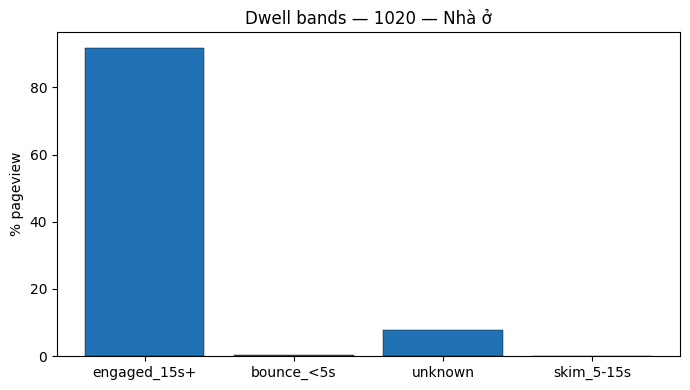

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g2_dwell_bands_1020.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,age_band,avg_dwell,n
0,0-2d,60089.828334,564294
1,3-7d,51633.535359,396125
2,8d+,54786.395087,1026406


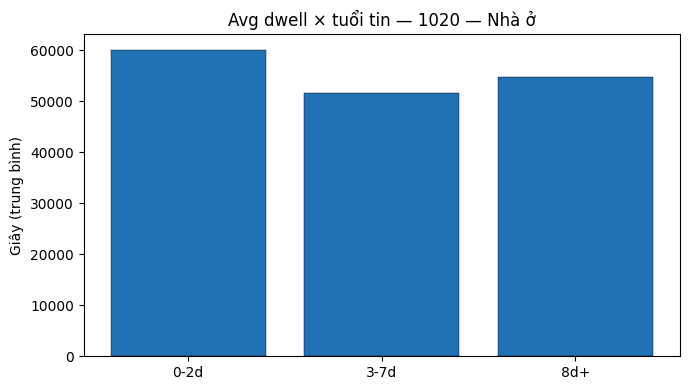

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g2_dwell_listing_age_1020.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Bẫy:** dwell cao, contact ≈ 0

,item_id,avg_dwell,pageviews,contacts
0,4540da946b692c67b16301854d0c45bc6532bc46f8627b...,3469325.0,1,0
1,e3b4e0f1ea8d40008116140133699eef16c59ef01a7450...,2705628.0,1,0
2,016a6de93c5ccc728cedfeebf0dbddff81c11e0018ccf3...,2662945.0,1,0
3,a6dc88da6eafa36b187ac50cdbaa969ea25cfe40c02b8d...,2619688.0,1,0
4,afbc0f30beb66647f3a5f728de1439a351a828c608be43...,2462361.0,1,0
5,71a7261968768de0487f96e991d8ad5ed7d56b2282a922...,2434914.0,1,1
6,bb406c19c8ed7a767548c1264839c7971780ea2e203cd6...,2379571.0,1,0
7,bfca9f0c22c42b246f15f5fc554f582b4eef1fb8b26468...,2235127.0,1,0
8,d4e0f23818405343e009c737ed48639b4dec178822d43c...,2219584.0,1,1
9,41c36a61263a9c31d8949fd1abb96a1cebc1c55e583835...,2189555.0,1,0


<IPython.core.display.Markdown object>


,dwell_band,n,pct
0,engaged_15s+,306672,92.292413
1,bounce_<5s,817,0.245875
2,unknown,24546,7.387077
3,skim_5-15s,248,0.074635


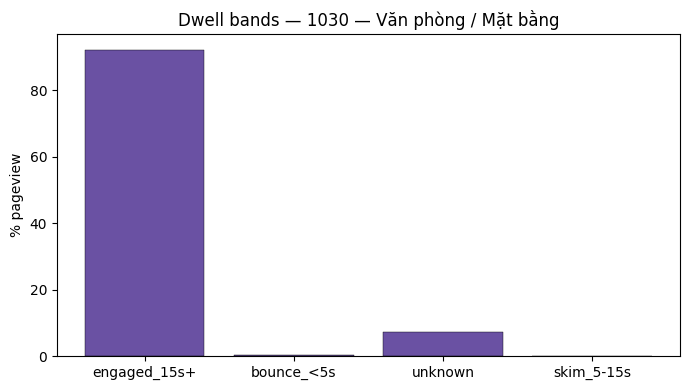

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g2_dwell_bands_1030.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,age_band,avg_dwell,n
0,0-2d,62929.424538,83691
1,3-7d,50322.618105,63177
2,8d+,52710.454417,161123


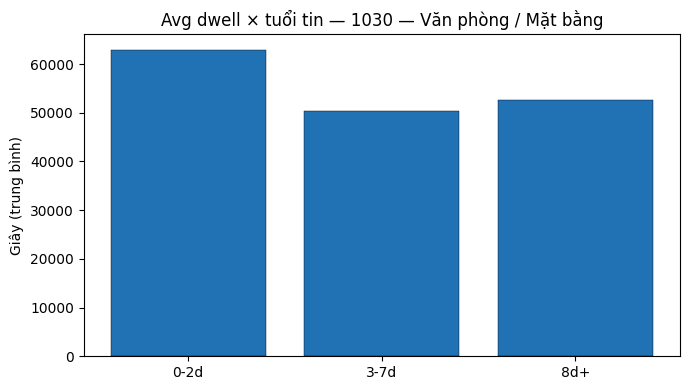

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g2_dwell_listing_age_1030.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Bẫy:** dwell cao, contact ≈ 0

,item_id,avg_dwell,pageviews,contacts
0,d8021db29de5d38ae8fb6f4e7d22748b38f5a67f457d98...,2354574.0,1,0
1,9ac88edff34da77330dece1623082f79e4d66e6a16f93e...,2128774.0,1,0
2,0a1a88bf7b80b4b67bf9ea01ede2fe8218ea0d1ebbca53...,2057916.0,2,0
3,ef70100c7f8af64f8b1713a50998403de22188d3a819f5...,2012160.0,1,1
4,32e87e86a465902077e81587d356836044a85a9e7757fc...,1820913.0,1,1
5,d0218e2ff6ba6a6dcb7ba3414e3f60307aeb52c1922a79...,1819141.0,1,0
6,596429551dafd50b72d38552d7f11008c9924c046299b9...,1795109.0,1,1
7,553c7296b5542a77f241378aed260e0713ab1ac8e409d8...,1722021.0,1,1
8,0cf4b15ff2e9c168c0b67d08b91e098b89b88fa3798880...,1696015.0,1,0
9,341f7a27889b62b007a44a928ea56f6fa7dc200b6508c5...,1695513.0,1,0


<IPython.core.display.Markdown object>


,dwell_band,n,pct
0,engaged_15s+,411559,89.889876
1,bounce_<5s,2141,0.467622
2,unknown,43769,9.559723
3,skim_5-15s,379,0.082779


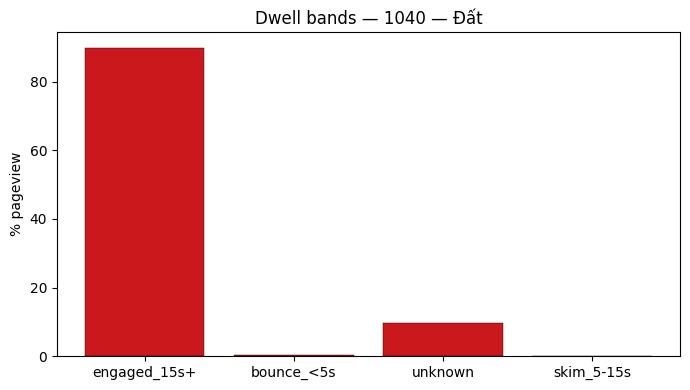

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g2_dwell_bands_1040.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,age_band,avg_dwell,n
0,0-2d,61936.790828,90925
1,3-7d,55734.548197,68355
2,8d+,59454.896713,256634


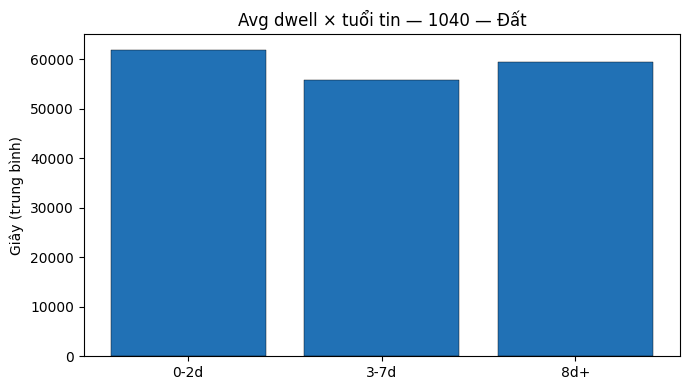

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g2_dwell_listing_age_1040.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Bẫy:** dwell cao, contact ≈ 0

,item_id,avg_dwell,pageviews,contacts
0,28923bed22a0b6363e17d6832f16688fb70b532c822dbc...,2293019.0,1,1
1,37a131642470ecb992424ffe8a21509e7b82de2146ffd7...,2195306.0,1,1
2,2c5ea375b807b2fbb6e839a910f0018e8ba9a87b5fd847...,1958218.0,1,0
3,732217b76f7be7a4cd70034a2b4b1babc1ab5364fb4052...,1904487.0,1,0
4,b90a2e6e354e25db6f71ea8f9d6b3f8e2dc1f3d5d5a121...,1845398.0,1,0
5,b12f3c7494079e1490b2a2aabd9879ad01eaa44dcad6dd...,1833933.0,1,0
6,c15068685753e68aa1671f9cf42781e28f199ce802936c...,1829604.0,1,0
7,2318405d098e32dbbc0627daa267eed8a7116b73182241...,1825978.0,1,1
8,25eac051c115f6d99872855e554779b55daa7348288ca3...,1824815.0,1,0
9,513cede62ff452df707a48ec6051d4d9b60f9ecdd3d8e9...,1785540.0,1,0


<IPython.core.display.Markdown object>


,dwell_band,n,pct
0,engaged_15s+,1379858,93.354947
1,bounce_<5s,4788,0.323934
2,unknown,92847,6.281608
3,skim_5-15s,584,0.039511


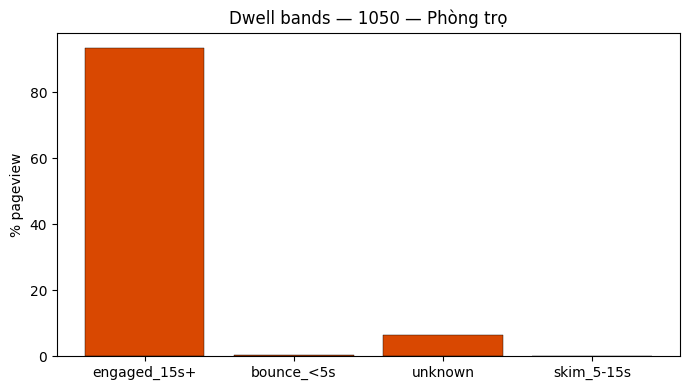

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g2_dwell_bands_1050.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,age_band,avg_dwell,n
0,0-2d,45488.255607,336736
1,3-7d,40993.977885,264387
2,8d+,44585.535584,786046


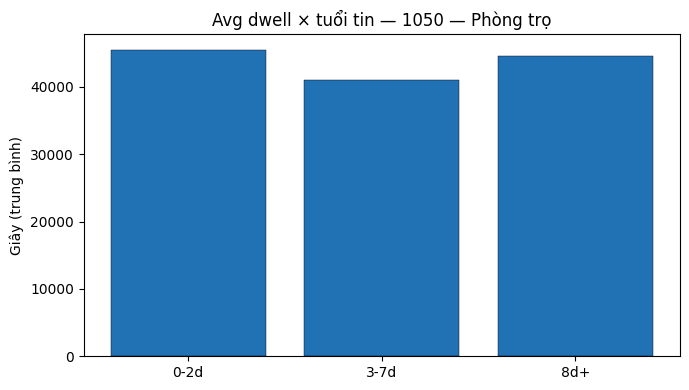

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g2_dwell_listing_age_1050.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Bẫy:** dwell cao, contact ≈ 0

,item_id,avg_dwell,pageviews,contacts
0,1cc05b5c59cbe045077a57d6285caa3c31c4382c9ae324...,2150540.0,1,1
1,3915e1385b7fb62c0cc1efc4eed83d565c8398d9803462...,1667093.0,1,1
2,7c6f024bcf8aee7f2d84573f301b6e6526bfa9d38508b9...,1643517.0,1,0
3,c955f17b7532ad6c02d43d5a7533877355c417bfbe6dde...,1616053.0,1,0
4,fae4e4ed2c3c3cb0d572296ec16867461b5a7c660ebe7f...,1615147.0,1,1
5,6276fb723491db01f5baa2cddb67a93b236e695b047c5f...,1503743.0,1,1
6,5ba751aa7309baaf36f5ac4f90bbe6abcc0f42466ff0d8...,1452797.0,1,0
7,365bb7ea5bc1b4f045fe91f5cbcde9eaff3bb29f80be36...,1421512.0,1,1
8,d89424cfbae8c142906fdaeb6b0dd9223eaca748ade3d1...,1270142.0,1,1
9,345ce3c8b478f58c09e7771cb14cc9d98ab2b60683992f...,1247887.0,1,1


In [5]:
def dwell_buckets(cat: int) -> pd.DataFrame:
    w = sample_clause(EVENT_SAMPLE_FRAC)
    return con.execute(
        f"""
        SELECT
            CASE
                WHEN dwell_time_sec < 5 THEN 'bounce_<5s'
                WHEN dwell_time_sec < 15 THEN 'skim_5-15s'
                WHEN dwell_time_sec IS NULL THEN 'unknown'
                ELSE 'engaged_15s+'
            END AS dwell_band,
            COUNT(*)::BIGINT AS n
        FROM read_parquet(?)
        WHERE category = ? AND event_type = 'pageview' {w}
        GROUP BY 1
        """,
        [EVENTS_GLOB, cat],
    ).fetchdf()


def dwell_by_listing_age(cat: int) -> pd.DataFrame:
    w = sample_clause(EVENT_SAMPLE_FRAC)
    return con.execute(
        f"""
        SELECT
            CASE
                WHEN s.listing_age_days <= 2 THEN '0-2d'
                WHEN s.listing_age_days <= 7 THEN '3-7d'
                ELSE '8d+'
            END AS age_band,
            AVG(e.dwell_time_sec) AS avg_dwell,
            COUNT(*)::BIGINT AS n
        FROM read_parquet(?) e
        INNER JOIN read_parquet(?) s ON e.item_id = s.item_id AND e.date = s.date
        WHERE e.category = ? AND e.event_type = 'pageview'
          AND e.dwell_time_sec IS NOT NULL AND s.listing_age_days IS NOT NULL {w}
        GROUP BY 1
        ORDER BY 1
        """,
        [EVENTS_GLOB, SNAP_GLOB, cat],
    ).fetchdf()


def dwell_traps(cat: int, limit: int = 30) -> pd.DataFrame:
    w = sample_clause(EVENT_SAMPLE_FRAC)
    return con.execute(
        f"""
        WITH pv AS (
            SELECT item_id,
                   AVG(dwell_time_sec) AS avg_dwell,
                   COUNT(*)::BIGINT AS pageviews
            FROM read_parquet(?)
            WHERE category = ? AND event_type = 'pageview' AND dwell_time_sec IS NOT NULL {w}
            GROUP BY item_id
        ),
        ct AS (
            SELECT item_id, COUNT(*)::BIGINT AS contacts
            FROM read_parquet(?)
            WHERE category = ? AND (is_contact = 1 OR event_type IN ({pos_list})) {w}
            GROUP BY item_id
        )
        SELECT p.item_id, p.avg_dwell, p.pageviews, COALESCE(c.contacts, 0) AS contacts
        FROM pv p LEFT JOIN ct c ON p.item_id = c.item_id
        WHERE p.avg_dwell >= (SELECT quantile_cont(avg_dwell, 0.95) FROM pv)
          AND COALESCE(c.contacts, 0) <= 1
        ORDER BY p.avg_dwell DESC
        LIMIT {limit}
        """,
        [EVENTS_GLOB, cat, EVENTS_GLOB, cat],
    ).fetchdf()


for cat in CATEGORIES_TO_RUN:
    name = CAT_META.loc[CAT_META["category"] == cat, "category_name"].iloc[0]
    print(Markdown(f"### Góc 2 — {name}"))
    db = dwell_buckets(cat)
    db["pct"] = pct_share(db["n"])
    display(db)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(db["dwell_band"], db["pct"], color=PALETTE[cat], edgecolor="black", linewidth=0.3)
    ax.set_ylabel("% pageview")
    ax.set_title(f"Dwell bands — {name}")
    show_and_save(f"g2_dwell_bands_{cat}.png", dpi=150)
    da = dwell_by_listing_age(cat)
    display(da)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(da["age_band"], da["avg_dwell"], color="#2171b5", edgecolor="black", linewidth=0.3)
    ax.set_ylabel("Giây (trung bình)")
    ax.set_title(f"Avg dwell × tuổi tin — {name}")
    show_and_save(f"g2_dwell_listing_age_{cat}.png", dpi=150)
    traps = dwell_traps(cat)
    display(Markdown("**Bẫy:** dwell cao, contact ≈ 0"))
    display(traps.head(10))




## Góc 3 — Contact, decay, desperation

<IPython.core.display.Markdown object>


event_type,contact_chat,contact_sms,contact_zalo,other_interaction,view_phone
device,,,,,
Android,2.0,0.2,0.1,95.1,2.6
Desktop,0.3,0.0,0.1,96.4,3.2
MSite,0.6,0.2,0.5,96.5,2.2
iOS,6.0,0.5,0.3,86.9,6.2


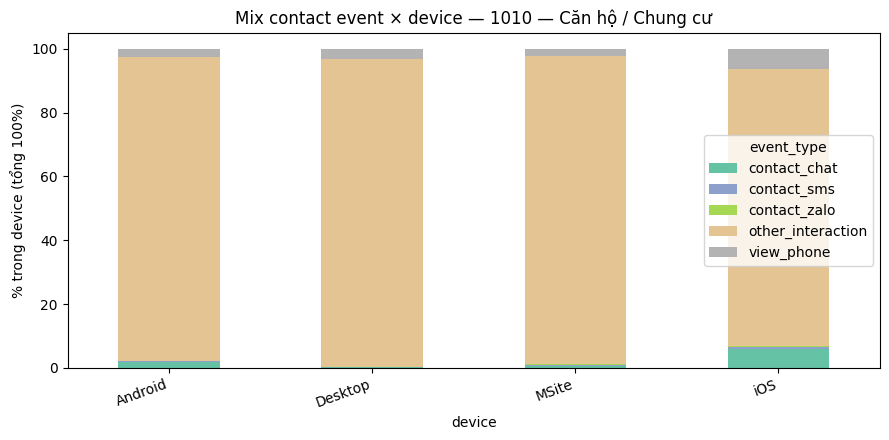

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g3_contact_device_1010.png


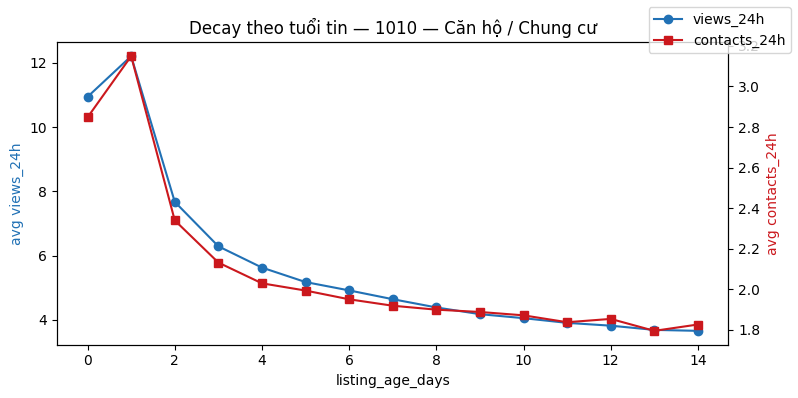

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g3_decay_1010.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,desperation_sessions,desperation_users
0,30298,23650


<IPython.core.display.Markdown object>


event_type,contact_chat,contact_sms,contact_zalo,other_interaction,view_phone
device,,,,,
Android,1.3,0.1,0.1,95.2,3.3
Desktop,0.3,0.0,0.1,94.9,4.8
MSite,0.4,0.2,0.5,95.9,3.0
iOS,3.3,0.4,0.2,88.2,8.0


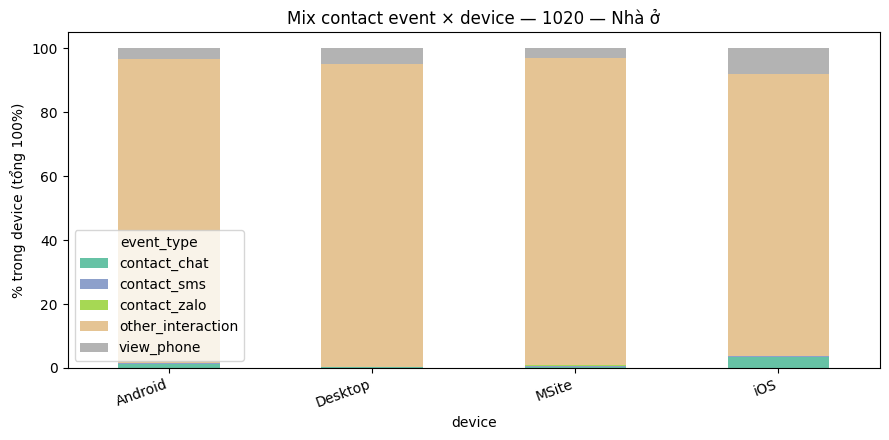

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g3_contact_device_1020.png


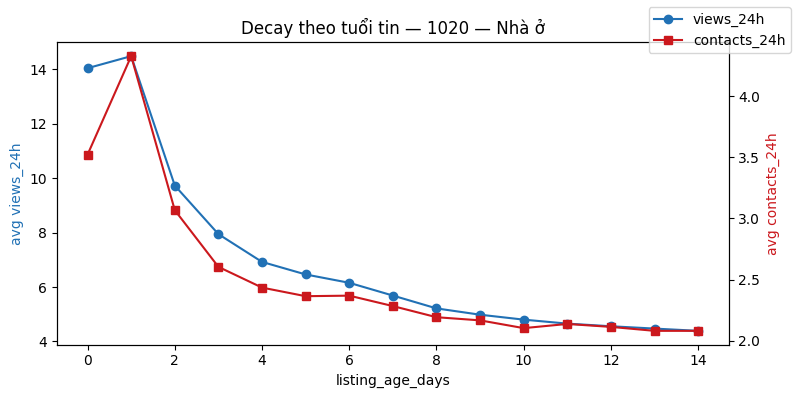

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g3_decay_1020.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,desperation_sessions,desperation_users
0,83179,54973


<IPython.core.display.Markdown object>


event_type,contact_chat,contact_sms,contact_zalo,other_interaction,view_phone
device,,,,,
Android,2.2,0.2,0.1,92.6,4.9
Desktop,0.3,0.0,0.1,93.5,6.2
MSite,0.4,0.2,0.5,94.9,4.0
iOS,5.0,0.5,0.2,81.4,12.8


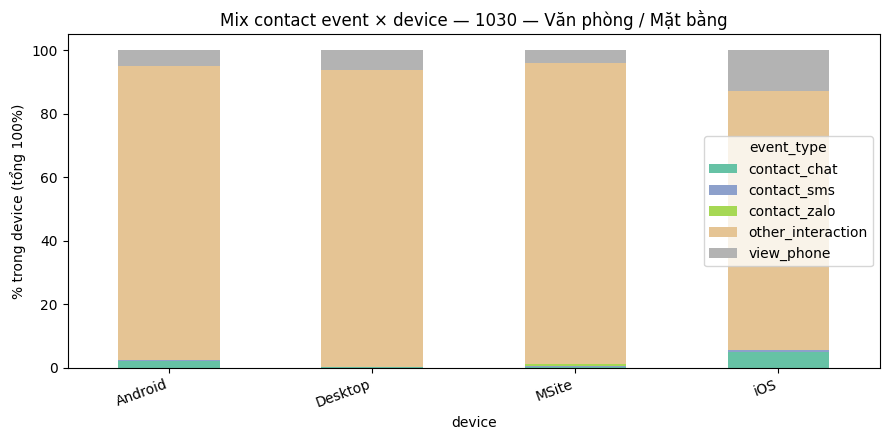

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g3_contact_device_1030.png


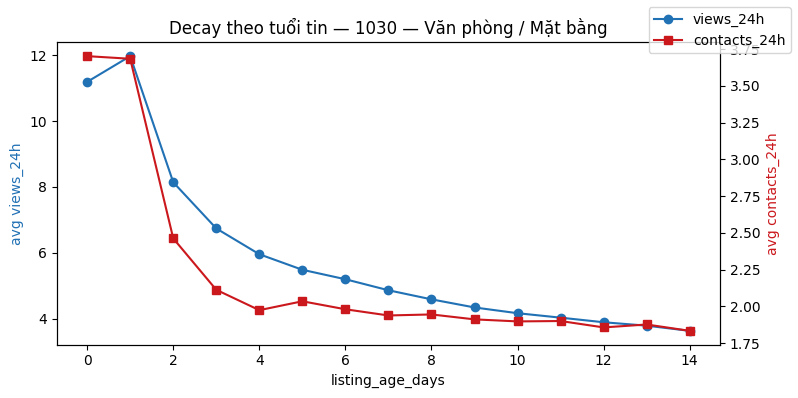

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g3_decay_1030.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,desperation_sessions,desperation_users
0,6705,5135


<IPython.core.display.Markdown object>


event_type,contact_chat,contact_sms,contact_zalo,other_interaction,view_phone
device,,,,,
Android,1.6,0.2,0.2,93.8,4.3
Desktop,0.5,0.0,0.1,92.3,7.2
MSite,0.5,0.2,0.5,94.7,4.0
iOS,4.5,0.6,0.3,81.1,13.5


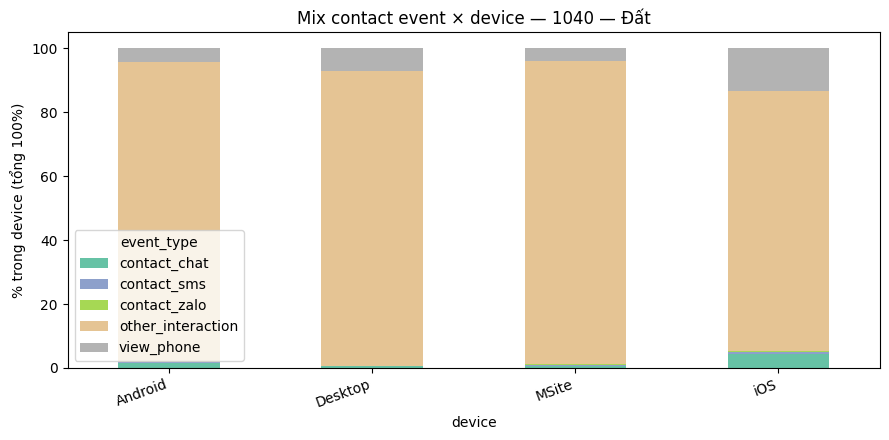

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g3_contact_device_1040.png


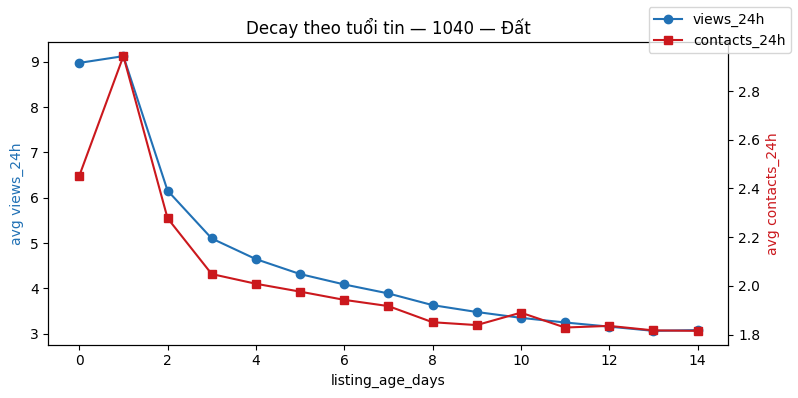

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g3_decay_1040.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,desperation_sessions,desperation_users
0,5562,4489


<IPython.core.display.Markdown object>


event_type,contact_chat,contact_sms,contact_zalo,other_interaction,view_phone
device,,,,,
Android,4.2,0.3,0.2,90.6,4.8
Desktop,0.4,0.0,0.1,96.8,2.7
MSite,0.6,0.2,0.6,95.7,2.9
iOS,9.2,0.6,0.4,80.8,8.9


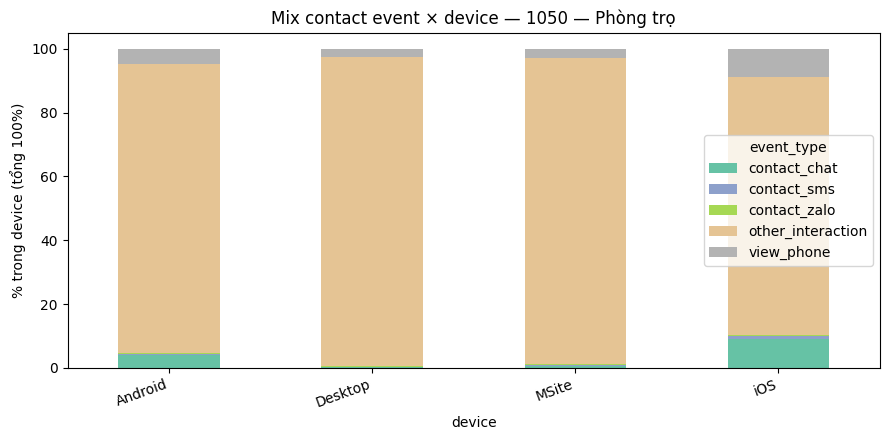

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g3_contact_device_1050.png


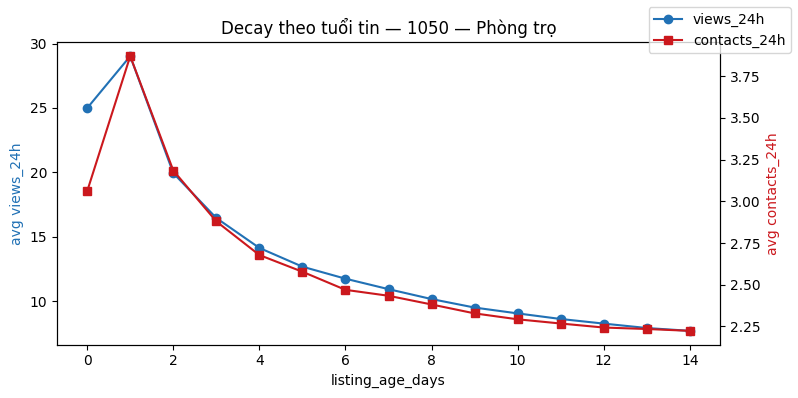

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g3_decay_1050.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,desperation_sessions,desperation_users
0,46699,35220


In [6]:
def contact_by_device(cat: int) -> pd.DataFrame:
    w = sample_clause(EVENT_SAMPLE_FRAC)
    return con.execute(
        f"""
        SELECT device, event_type, COUNT(*)::BIGINT AS n
        FROM read_parquet(?)
        WHERE category = ? AND event_type IN ({pos_list}) {w}
        GROUP BY 1, 2
        """,
        [EVENTS_GLOB, cat],
    ).fetchdf()


def decay_by_age(cat: int) -> pd.DataFrame:
    return con.execute(
        """
        SELECT CAST(s.listing_age_days AS INT) AS listing_age_days,
               AVG(s.views_24h) AS avg_views_24h,
               AVG(s.contacts_24h) AS avg_contacts_24h
        FROM read_parquet(?) s
        INNER JOIN read_parquet(?) d
          ON CAST(s.item_id AS VARCHAR) = CAST(d.item_id AS VARCHAR)
        WHERE d.category = ? AND s.listing_age_days BETWEEN 0 AND 14
        GROUP BY 1 ORDER BY 1
        """,
        [SNAP_GLOB, DIM_GLOB, cat],
    ).fetchdf()


def desperation_users(cat: int) -> pd.DataFrame:
    w = sample_clause(EVENT_SAMPLE_FRAC)
    return con.execute(
        f"""
        WITH ev AS (
            SELECT user_id, session_id, item_id, event_ts,
                   date_trunc('minute', event_ts) AS minute_bucket
            FROM read_parquet(?)
            WHERE category = ? AND event_type IN ({pos_list})
              AND user_id IS NOT NULL {w}
        ),
        sess AS (
            SELECT user_id, session_id,
                   COUNT(DISTINCT item_id) AS distinct_items,
                   COUNT(*) AS contact_events
            FROM ev
            GROUP BY user_id, session_id
            HAVING COUNT(DISTINCT item_id) >= 5
        )
        SELECT COUNT(*)::BIGINT AS desperation_sessions,
               COUNT(DISTINCT user_id)::BIGINT AS desperation_users
        FROM sess
        """,
        [EVENTS_GLOB, cat],
    ).fetchdf()


for cat in CATEGORIES_TO_RUN:
    name = CAT_META.loc[CAT_META["category"] == cat, "category_name"].iloc[0]
    print(Markdown(f"### Góc 3 — {name}"))
    cd = contact_by_device(cat)
    if not cd.empty:
        pivot = cd.pivot_table(index="device", columns="event_type", values="n", fill_value=0)
        pivot_pct = pct_row(pivot)
        display(pivot_pct.round(1))
        fig, ax = plt.subplots(figsize=(9, 4.5))
        pivot_pct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
        ax.set_ylabel("% trong device (tổng 100%)")
        ax.set_title(f"Mix contact event × device — {name}")
        plt.xticks(rotation=20, ha="right")
        show_and_save(f"g3_contact_device_{cat}.png", dpi=150)
    dec = decay_by_age(cat)
    if not dec.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax2 = ax.twinx()
        ax.plot(dec["listing_age_days"], dec["avg_views_24h"], color="#2171b5", label="views_24h", marker="o")
        ax2.plot(dec["listing_age_days"], dec["avg_contacts_24h"], color="#cb181d", label="contacts_24h", marker="s")
        ax.set_xlabel("listing_age_days")
        ax.set_ylabel("avg views_24h", color="#2171b5")
        ax2.set_ylabel("avg contacts_24h", color="#cb181d")
        ax.set_title(f"Decay theo tuổi tin — {name}")
        fig.legend(loc="upper right")
        show_and_save(f"g3_decay_{cat}.png", dpi=150)
    desp = desperation_users(cat)
    display(desp)



## Góc 4 — Content quality: `other_interaction` → explicit

- Browse funnel (bước 1–3): **cả login + non-login**
- Outcome explicit: `view_phone` / `zalo` / `sms` không lọc login; **`contact_chat` verified** = login + `chat_message_count > 0` (join interactions)
- KPI lead: **không** gom `other_interaction` vào explicit
- SQL/charts: module [`eda_engagement_g4_module.py`](eda_engagement_g4_module.py)

In [7]:
from eda_engagement_g4_module import run_corner4_category, cross_lift_summary

def _run_g4_all(categories=None):
    categories = categories or CATEGORIES_TO_RUN
    parts = []
    for cat in categories:
        label = CAT_META.loc[CAT_META["category"] == cat, "category_name"].iloc[0]
        display(Markdown(f"### Góc 4 — {label}"))
        ab = run_corner4_category(
            con, cat, EVENTS_GLOB, INTER_GLOB, DIM_GLOB, SNAP_GLOB,
            OUT_DIR, OUT_CSV, EVENT_SAMPLE_FRAC, PALETTE[cat],
        )
        display(ab)
        parts.append(ab)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

ab_all = _run_g4_all(CATEGORIES_TO_RUN)
print("Góc 4 charts/CSV →", OUT_DIR, "| tables →", OUT_CSV)



### Góc 4 — 1010 — Căn hộ / Chung cư

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,grp,sessions,view_phone_pct,contact_chat_raw_pct,contact_chat_verified_pct,contact_zalo_pct,contact_sms_pct,explicit_any_pct,category,category_label
0,co_other_interaction,302572,6.328,3.067,2.148,0.676,0.278,9.043,1050,1050 — Phòng trọ
1,khong_other,501388,2.246,1.942,1.435,0.135,0.141,3.833,1050,1050 — Phòng trọ


Góc 4 charts/CSV → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement | tables → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_engagement/g4_tables


## Góc 4 — Tổng hợp cross-category

**Lưu ý dwell:** `other_interaction` không có `dwell_time_sec` trong raw events → chart `g4_dwell_violin_*` dùng **proxy p50 pageview dwell** trên session×item (có/không OI).

- ~95% `other_interaction` có `surface=ad_view` (`outputs/is_contact_composition/`).
- Path session×item (login): 1010 A **4.59%** vs B **12.51%** explicit (`eda_contact_rate_weights/1010/`).
- `contact_chat_verified_pct` ≤ `contact_chat_raw_pct` mọi category.
- Nhóm **có other_interaction** có `explicit_any_pct` cao hơn **không other**.
- `pv_explicit_skip_oi` > 0 → user liên hệ không qua bước soi ảnh.



In [8]:
lift = cross_lift_summary(ab_all, OUT_CSV, OUT_DIR)
display(lift)

,category,category_label,explicit_any_khong_other_pct,explicit_any_co_other_pct,lift_pp
0,1010,1010 — Căn hộ / Chung cư,3.241,7.309,4.068
1,1020,1020 — Nhà ở,4.054,9.343,5.289
2,1030,1030 — Văn phòng / Mặt bằng,3.377,8.985,5.608
3,1040,1040 — Đất,3.142,7.961,4.819
4,1050,1050 — Phòng trọ,3.833,9.043,5.210
